# Decision Trees

<b>Nodes</b> 
* Determine where our data will travel
* Effectively they are the points of decisions being made (something like a precipitation node being sunny or rainy)

<b>Root Node</b>
* The node that performs the first split

<b>Decision Node:</b> 
* Contains a condition which splits the data

<b>Pure Node</b> 
* Only one class remains
* Represents a situation where a decision has been made with 100% certainty (or with a high degree of confidence, depending on the definition of purity)
* No further splitting of that node is necessary
* Can be a leaf node if no further splitting of data is needed

<b>Leaf Node</b> 
* Terminal nodes that determine the outcome
* In other words, determines the class of a new data point
* Is not inherently pure because it can contain multiple classes

<b>Edges</b> 
* These would be the actual travel path itself (sunny vs rainy)
* If sunny go down left branch (edge), if rainy then go down right branch

<b>Overall Notes</b>
* Decision Trees are basically a bunch of if/else statements, BUT:
* The machine learning aspect of decision trees accounts for many different conditions that can be present, and helps decide the optimal amount of splits to make
* Goal is to get <b>pure leaf nodes</b>
* Model will choose the split that maximizes the <b>Information Gain</b>
* <b>HIGHLY SENSITIVE TO TRAINING DATA</b> (which could result in high variance)

<b>Information Gain</b><br>
* <b>Entropy:</b>
  * Before splitting, the dataset has a certain level of entropy, which represents the amount of randomness or impurity.
  * If entropy is high, then we are very uncertain about the randomly picked new data point
  * Highest value for entropy is 1 (maximum uncertainty)
  * Minimum value for entropy is 0 (minimum uncertainty, node resulting in one class(pure node))
* <b>Splitting:</b>
When a dataset is split based on a specific feature, the entropy of the resulting subsets decreases. 
* <b>Information Gain:</b>
The information gain is calculated as the difference between the entropy of the original dataset and the weighted average of the entropies of the subsets. 
* <b>Choosing Features:</b>
The feature with the highest information gain is chosen to split the dataset at a given node, as it leads to the greatest reduction in entropy and a more homogeneous set of data. 

# Random Forests

* Primary weakness of decision trees is that they don't have the best predictive accuracy.
* Random Forests are a collection of multiple random decision trees, and much less sensitive to the training data.
* Random Forests "decorrelates" the decision trees, so we can reduce variance of our resulting model.

<b>Creating a Random Forest</b>
* Build new datasets from our original data (AKA: Bootstrapping)
  * Randomly select rows from original data to build new dataset
  * Every new dataset will contain the same number of rows as the original
* Build decision trees with random selection of a few features from original data
  * Process new data points through each randomly create tree
* For our classification problem, we take the outcome which holds the majority (AKA: Aggregation)
  * If in binary classification, we have 3 outcomes of value "1", and 1 outcome of value "0", then we take value 1

<b>Overall Notes</b> <br>
<b>Why is it called "Random" Forest?</b>
  * Because we have used two random processes (bootstrapping, and random feature selection)

<b>Motivation behind bootstrapping and random feature selection?</b>
  * Bootstrapping:
    * Ensures that we are not using the same data for every tree
    * Helps our data not be sensitive to the original training data
  * Random Feature Selection
    * Helps reduce the correlation between the trees
    * If we use the same features between trees, then most trees will have same decision nodes (and act similarly)
    * Some of the trees will be trained on less important features, leading to bad predictions (but other trees training on good features will balance this out)

<b>How many features to use for each tree?</b>
* Research has shown the square root to the number of features works well
* Ex: Use 2 features for the feature subset when total number of features is 5

<b>Bootstrapping + Aggregation = "Bagging"</b>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Kyphosis Data

* <b>Kyphosis:</b> Whether the spinal condition "Kyphosis" is <i>absent</i> or <i>present</i>
* <b>Age:</b> The age of the individual in <i>months</i>
* <b>Number:</b> The number of <i>vertebrae</i> involved in the operation
* <b>Start:</b> The number (top most) vertebrae that was operated on

In [2]:
df = pd.read_csv("kyphosis.csv")
df

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15
...,...,...,...,...
76,present,157,3,13
77,absent,26,7,13
78,absent,120,2,13
79,present,42,7,6


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Kyphosis  81 non-null     object
 1   Age       81 non-null     int64 
 2   Number    81 non-null     int64 
 3   Start     81 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 2.7+ KB


In [4]:
df.describe()

,Age,Number,Start
count,81.000000,81.000000,81.000000
mean,83.654321,4.049383,11.493827
std,58.104251,1.619423,4.883962
min,1.000000,2.000000,1.000000
25%,26.000000,3.000000,9.000000
50%,87.000000,4.000000,13.000000
75%,130.000000,5.000000,16.000000
max,206.000000,10.000000,18.000000


In [5]:
df.shape

(81, 4)

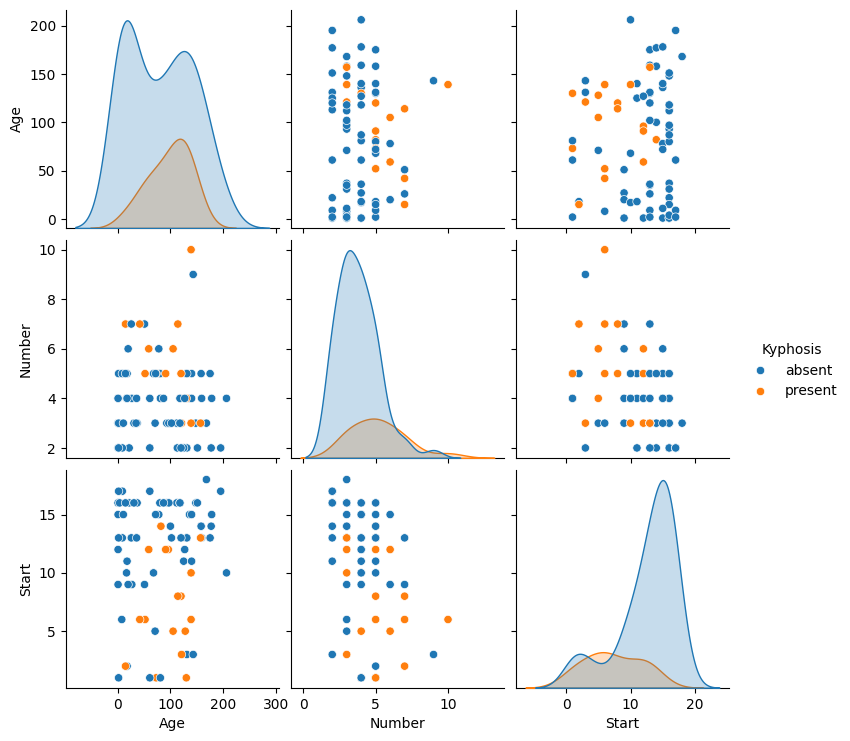

In [6]:
sns.pairplot(df, hue='Kyphosis')

### Decision Tree - Model Building

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X = df.drop('Kyphosis', axis=1)
y = df['Kyphosis']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [10]:
from sklearn.tree import DecisionTreeClassifier

In [11]:
dtree = DecisionTreeClassifier()

In [12]:
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

In [13]:
predictions = dtree.predict(X_test)

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

In [19]:
print(confusion_matrix(y_test, predictions))

[[18  1]
 [ 3  3]]


Interpretation:

* <b>True Negatives (TN)</b> = 18 Predicted class "absent" and actually class "absent"
* <b>False Positives (FP)</b> = 1 Predicted class "present" but actually class "absent"
* <b>False Negatives (FN)</b> = 3 Predicted class "absent" but actually class "present"
* <b>True Positives: (TP)</b> = 3 Predicted class "present" and actually class "present"

In [18]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

      absent       0.86      0.95      0.90        19
     present       0.75      0.50      0.60         6

    accuracy                           0.84        25
   macro avg       0.80      0.72      0.75        25
weighted avg       0.83      0.84      0.83        25

